In [1]:
import pygrib as pg
import numpy as np
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import import_ipynb
import time
import os
import math
import warnings

In [2]:
#Intializing lats, lons, and elevation

grib_file = '/adata/afarguell/fmce/data/hrrr_data/hrrr.20150323/hrrr.t22z.wrfprsf00.grib2'
grbs = pg.open(grib_file)

# Find the GRIB message for orography (elevation)
orog_message = None
for grb in grbs:
    if grb.shortName == 'orog':  # Orography
        orog_message = grb
        break
        
if orog_message:
    # Get the latitude and longitude values
    lats, lons = orog_message.latlons()

    # Get the elevation values
    elevation = orog_message.values

grbs.close()

In [3]:
def month_data(file_path):
    grbs = pg.open(file_path)
    first_grb = grbs.message(1)
    timestamp = first_grb.validDate
    grbs.close()
    return timestamp.month

In [4]:
def hrrr_data(dir_path):
    '''This function lets find the location of all hrrr data'''
    files = os.listdir(dir_path)
    paths = []
    for file in files:
        paths.extend([dir_path + '/' + file])
    return paths 

In [5]:
def files(dir_path):
    '''Filters out the .size files in the hrrr data'''
    files = os.listdir(dir_path)   
    paths = []
    #Looping thorugh all of the files
    for file in files:
        if file.endswith('.grib2') and not file.endswith('.size'):
            paths.extend([dir_path + '/' + file])
    return paths

In [6]:
def data(grib_file, parameter_name, level_type, level):
    with pg.open(grib_file) as grbs:
        for grb in grbs:
            if grb.name == parameter_name and grb.typeOfLevel == level_type and grb.level == level:
                data = grb.values
                #lats, lons = grb.latlons()
                return data
    raise ValueError("No matches found")

In [7]:
hrrr_paths = []
hrrr_paths.extend(hrrr_data('/adata/afarguell/fmce/data/hrrr_data'))
all_files = []
for h in hrrr_paths:
    all_files.extend([files(h)])

In [8]:
def year_precip(tot, day):
    return tot / (day / 365)

def day_precip(tot, day):
    return tot / day

In [9]:
def LFP(T, DEW, WS):
    '''Large Fire Potential 
    PARAMETERS
    ----------
    WS :=  Sustained Wind Speed
    D := Dewpoint in K
    '''
    T = (T - 273.15) * 9/5 + 32 
    DEW = (DEW - 273.15) * 9/5 + 32 
    D = (T - DEW) 
    WS = 2.23694
    return 0.001 * np.power(WS, 2) * D

In [10]:
def month_to_day_of_year(month):
    """ Convert month to an approximate day of the year (mid-month) """
    return (month - 0.5) * 30

def solar_declination(day_of_year):
    """ Calculate solar declination """
    return 23.45 * np.sin(np.radians((360/365) * (day_of_year - 81)))

def hour_angle(latitude, solar_declination):
    """ Calculate hour angle """
    lat_rad = np.radians(latitude)
    dec_rad = np.radians(solar_declination)
    return np.degrees(np.arccos(-np.tan(lat_rad) * np.tan(dec_rad)))

def day_length(latitude, month):
    """ Estimate the day length based on latitude and month """
    day_of_year_val = month_to_day_of_year(month)
    declination = solar_declination(day_of_year_val)
    h_angle = hour_angle(latitude, declination)
    return 2 * h_angle / 15  # Convert hour angle to time in hours
    
def DMC(TEMP, RH, RAIN, DMCPrev, LAT, MONTH):
    '''Calculates today's Duff Moisture Code

    PARAMETERS
    ----------
    TEMP is the 12:00 LST temperature in degrees celsius
    RH is the 12:00 LST relative humidity in %
    RAIN is the 24-hour accumulated rainfall in mm, calculated at 12:00 LST
    DMCPrev is the previous day's DMC
    LAT is the latitude in decimal degrees of the location for which calculations are being made
    Month is the month of Year (1..12) for the current day's calculations.

    USAGE:
    DMC(17,42,0,6,45.98,4) = 8.5450511359999997'''

    TEMP = TEMP - 273.15
    
    RH = np.minimum(100.0, RH)
    
    re = np.where(RAIN > 1.5, 
         0.92 * RAIN - 1.27, 0)

    mo = np.where(RAIN > 1.5,
            20.0 + np.exp(5.6348 - DMCPrev / 43.43), 0)
    
    b = np.where(RAIN > 1.5, 
                 np.where(DMCPrev <= 33.0, 
                 100.0 / (0.5 + 0.3 * DMCPrev),
                 np.where(DMCPrev <= 65.0,
                        14.0 - 1.3 * np.log(DMCPrev),
                        6.2 * np.log(DMCPrev) - 17.2)), 
                 0)
    
    mr = np.where(RAIN > 1.5,
             mo + 1000.0 * re / (48.77 + b * re),
             0)
    
    pr = np.where(RAIN > 1.5,
            244.72 - 43.43 * np.log(mr - 20.0),
            0)
    
    DMCPrev = np.where(RAIN > 1.5, 
             np.where(pr > 0,
                       pr,
                       0.0), DMCPrev)

    k = np.where(TEMP > -1.1, 
                 np.where(MONTH, 
                          1.894 * (TEMP + 1.1) * (100.0 - RH) * day_length(LAT, MONTH)  * 0.000001, 
                          1.894 * (TEMP + 1.1) * (100.0 - RH) * 6.0 * 0.000001), 
                 0.0)

    return DMCPrev + 100.0 * k

In [11]:
def ISI(WIND, FFMC):
    '''Calculates the Initial Spread Index (ISI)
    
    WIND is the 12:00 LST wind speed in kph
    FFMC is the current day's FFMC

    USAGE:
    ISI(25,87.692980092774448) = 10.853661073655068'''
    
    fWIND = np.exp(0.05039 * WIND)
    m = 147.2 * (101.0 - FFMC) / (59.5 + FFMC)
    fF = 91.9 * np.exp(-0.1386 * m) * (1.0 + np.power(m, 5.31) / 49300000.0)
    ISI = 0.208 * fWIND * fF
    return ISI

In [12]:
def WS(U, V):
    '''Calculates Wind Speed using U and V
    VARIBLES
    --------
    U : Wind speed from south to north
    V : Wind speed from east to west'''
    
    return np.sqrt(U**2 + V**2)
    
def ko(RH, WIND):
    '''Calculates the drying rate coefficent
    VARIBLES
    --------
    RH : Relative Humidity
    WIND : Wind Speed'''
    
    return 0.424 * (1.0 - np.power((RH / 100.0), 1.7)) + 0.0694 * np.power(WIND, 0.5) * (1.0 - np.power((RH / 100.0), 8))

def kd(ko, TEMP):
    '''Calculates the moisture damping coefficent
    VARIBLES
    --------
    ko : Drying rate coefficent
    TEMP : Temprature (K)'''
    
    TEMP = TEMP - 273.15
    return ko * 0.581 * np.exp(0.0365 * TEMP)

In [13]:
def FFWI(U, n):
    ''' Forsberg Fire Weather Index 
    PARAMATERS
    ----------
    U :=  Wind speed (mph)
    n := moisture damping coefficent
    '''
    
    return n * (np.sqrt(1 + U**2)) / 0.3002

In [14]:
def calc_mo(FFMCPrev):
    return 147.2 * (101.0 - FFMCPrev) / (59.5 + FFMCPrev)
    
def FFMC(TEMP, RH, WIND, RAIN, FFMCPrev):

    RH = np.minimum(100.0, RH)
    mo = calc_mo(FFMCPrev)

    rf = np.where(RAIN > 0.5, 
                RAIN - 0.5, 0)
    mr = np.where(RAIN > 0.5,
                mo + \
                42.5 * rf * np.exp(-100.0 / (251.0 - mo)) * \
                (1.0 - np.exp(-6.93 / rf)), 0)
    mr = np.where(RAIN > 0.5,
                  np.where(mo <= 150.0,
                           mr,
                           mr + 0.0015*np.power(mo - 150.0, 2) * np.power(rf, 2)), mo)

    mr = np.where(RAIN > 0.5,
                  np.where(mr > 250.0, 250, mr), mo)

    mo = np.where(RAIN > 0.5, 
                  mr, mo)
                  
    ed = 0.942 * np.power(RH, 0.679) + \
            11.0*np.exp((RH - 100) / 10.0) + 0.18 * (21.1 - TEMP) * \
            (1.0 - np.exp(-0.115 * RH))

    m = np.where(mo > ed,
                 m1(TEMP, RH, WIND, RAIN, FFMCPrev, mo, ed),
                 m2(TEMP, RH, WIND, RAIN, FFMCPrev, mo))

    ffmc = 59.5 * (250.0 - m) / (147.2 + m)
    ffmc = np.minimum(101.0, ffmc)
    ffmc = np.maximum(0, ffmc)
    return ffmc
   
    
def m1(TEMP, RH, WIND, RAIN, FFMCPrev, mo, ed):    
    ko = 0.424 * (1.0 - np.power(RH / 100.0, 1.7)) + \
         0.0694 * np.power(WIND, 0.5) * (1.0 - np.power(RH / 100, 8))

    kd = ko * 0.581 * np.exp(0.0365 * TEMP)

    m = ed + (mo - ed) * np.power(10.0, -kd)
    return m

def m2(TEMP, RH, WIND, RAIN, FFMCPrev, mo):
    ew = 0.618 * np.power(RH, 0.753) + \
         10.0 * np.exp((RH - 100.0) / 10.0) + \
         0.18 * (21.1 - TEMP) * (1.0 - np.exp(-0.115 * RH))

    k1 = np.where(mo < ew,
             0.424 * (1.0 - np.power((100.0 - RH) / 100.0, 1.7)) + \
             0.0694 * np.power(WIND, 0.5) * (1.0 - np.power((100.0 - RH) / 100.0, 8)),
             0)

    kw = np.where(mo < ew,
                  k1 * 0.581 * np.exp(0.365 * TEMP), 0)

    m = np.where(mo < ew,
                 ew - (ew - mo) * np.power(10.0, -kw), mo)

    return m

In [15]:
def Green_up(t_max, t_min, t_base):
    '''Calculates the Green-Up Index
    VARIBLES
    --------
    T_max: Max Temprature (K)
    T_min: Minimum Temprature (K)
    T_base: Base Temprature (K)'''
    t_max -= 273.15
    t_min -= 273.15
    t_base -= 273.15
    return ((t_max + t_min) / 2) - t_base

def dfm(df, a = 0.5, b = 0.1, c = -0.3, d = 0.05):
    """
    Calculate Dead Fuel Moisture (DFM).
    
    :param df: DataFrame with columns ['temperature', 'relative_humidity', 'wind_speed']
    :param a, b, c, d: Coefficients for the DFM model
    :return: DataFrame with DFM values
    """
    return a + b * df['T'] + c * df['RH'] + d * df['WS']
    

def lfm(df, a = 10, b = -0.3, c = 0.5, d = 0.2):
    """
    Calculate Live Fuel Moisture (LFM).
    
    :param df: DataFrame with NDVI values
    :param e, f: Coefficients for the LFM model
    :return: DataFrame with LFM values
    """
    return a + b * df['T'] + c * df['RH'] + d  * df['RAIN']

def FMC(DL, LFM, G):
    '''Calculates the Fuel Moisture Content
    VARBILES
    --------
    DL: Dead Fuel Moisture
    LFM: Live Fuel Moisture
    G: Green Up Degree'''
    LFM = LFM.replace(0, 0.001)
    rv = (0.1 * ((DL / LFM) - 1))
    rv = rv + G
    rv = np.power(np.abs(rv), 1.7)
    return rv

def FMC_1(FFMC):
    fmc = 147.2 * (101 - FFMC) / (59.5 + FFMC)
    return np.abs(fmc)
    
def SAWTI(WS, D, FMC):
    '''Calculates Santa Anna Wildfire Threat Index
    VARIBLES
    --------
    WS: Wind Speed
    D: Dew Point Depression (F)
    FMC: Fuel Moisture Content'''
    D = (D - 273.15) + 9/5 + 32
    return 0.001 * np.power(WS, 2) * D / FMC  #Should be multiplied. However, divide makes more sense

In [16]:
def ET(T, P, old_kbdi):
    '''Calculates the Potential Evapotranspiration (PET)

    PARAMETERS
    ----------
    Maximum Temperature (T)
    Average Annual Precipitation (P)
    Previous Day's KBDI (old_kbdi)'''
    
    P = P / 25.4    #Convert from mm -> In
    pet = 0.001 * (203.2 - old_kbdi)
    pet *= (0.968 * np.exp(0.0875 * T + 1.5552) - 8.30)
    pet /= (10.88 * np.exp(-0.001736 * P) + 1)
    return pet

def KBDI(T, R, P, old_kbdi):
    '''Calculates the Keetch-Byram Drought Index (KBDI)

    PARAMETERS
    ----------
    Daily Max Temperature in Fahrenheit (T)
    Daily Rainfall in Inches (R)
    Average Annual Precipitation (P)
    Previous day's KBDI - initially set to 0 (old_kbdi)'''

    R = R / 25.4
    P = P / 25.4
    T = (T - 273.15) * 9/5 + 32
    pet = ET(T, P, old_kbdi)
    
    # Adjust old KBDI based on rainfall
    kbdi_rain_adjusted = old_kbdi - 100 * R
    kbdi_rain_adjusted = np.where(kbdi_rain_adjusted < 0,
                                  0, kbdi_rain_adjusted)
    
    # Calculate new KBDI
    kbdi = kbdi_rain_adjusted + pet
    kbdi = np.maximum(0, kbdi)  # KBDI cannot be less than 0
    kbdi = np.minimum(kbdi, 800)  # KBDI cannot be more than 800
    
    return kbdi

In [17]:
def Haines(t_950, t_850, t_700, t_500, t_dew850, t_dew700, height):
    '''Calculates the Haines Index

    PARAMETERS
    -----------
    - t_950 : Temprature at 950 atm (K).
    - t_850 : Temprature at 850 atm (K).
    - t_700 : Temprature at 700 atm (K).
    - t_500 : Temprature at 500 atm (K).
    - t_dew850 : Dew Point Temprature at 850hPa (K).
    - t_dew700 : Dew Point Temprature at 700hPa (K).
    - height : Height above sea level
    '''
    
    h = np.where(height < 304.8,
             Haines_low(t_950, t_850, t_dew850),
             np.where(height < 914.4,
                      Haines_mid(t_850, t_700, t_dew850),
                      Haines_high(t_700, t_500, t_dew700)))
                      
    return h

def Haines_low(t_950, t_850, t_dew850):
    #Find Stability Score   
    A = 0
    A = t_950 - t_850
    A = np.where(A <= 3, 
                1, 
                 np.where(A <= 7,
                          2, 3))
    
    #Find Moisture Score
    B = 0
    B = t_850 - t_dew850
    B = np.where(B <= 5,
                 1,
                 np.where(B <= 9,
                          2, 3))
    
    return A + B

def Haines_mid(t_850, t_700, t_dew850):
    #Find Stability Score   
    A = 0
    A = t_850 - t_700
    A = np.where(A <= 5, 
                1, 
                 np.where(A <= 10,
                          2, 3))
    
    #Find Moisture Score
    B = 0
    B = t_850 - t_dew850
    B = np.where(B <= 5,
                 1,
                 np.where(B <= 12,
                          2, 3))
    
    return A + B

def Haines_high(t_700, t_500, t_dew700):
    #Find Stability Score   
    A = 0
    A = t_700 - t_500
    A = np.where(A <= 17, 
                1, 
                 np.where(A <= 21,
                          2, 3))
    
    #Find Moisture Score
    B = 0
    B = t_700 - t_dew700
    B = np.where(B <= 14,
                 1,
                 np.where(B <= 20,
                          2, 3))
    
    return A + B

In [18]:
def carry_on_data(dataframes, temperature_column='T', precipitation_column = 'RAIN'):
    """
    This function takes a list of dataframes and returns a dataframe with the highest temperature value
    at each data point.
    
    :param dataframes: List of pandas dataframes containing temperature data
    :param temperature_column: The name of the column containing temperature values
    :return: A dataframe with the highest temperature values at each data point
    """
    global carry_on
    print(type(dataframes))
    # Concatenate dataframes along the columns for temperature and precipitation
    temp_dfs = [df[[temperature_column]] for df in dataframes]
    precip_dfs = [df[[precipitation_column]] for df in dataframes]
    print('HI')
    concatenated_temp_df = pd.concat(temp_dfs, axis=1)
    concatenated_precip_df = pd.concat(precip_dfs, axis=1)
    
    # Find the maximum temperature value at each data point
    max_temperatures = concatenated_temp_df.max(axis=1)

    #Find the minimum tempratures at each data point
    min_tempratures = concatenated_temp_df.min(axis=1)

    day_precipitation = concatenated_precip_df.sum(axis=1)
    # Calculate the total precipitation at each data point
    if 'precip' in carry_on :
        total_precipitation =  day_precipitation + carry_on['precip']
    else:
        total_precipitation =  day_precipitation
    # Create a new dataframe to store the results
    result_df = pd.DataFrame({
        't_max': max_temperatures,
        't_min': min_tempratures,
        'day_precip' : day_precipitation,
        'precip' : total_precipitation,
        'DMC' : dataframes[-1]['DMC'],
        'FFMC' : dataframes[-1]['FFMC'],
        'KBDI' : dataframes[-1]['KBDI']
        
    })
    
    return result_df

In [124]:
def create_varibles(file_path, carry_on, days, lats, lons, elevation):

    latitude_range = (40, 41)  # Latitude range for Carr Fire
    longitude_range = (-123, -122)  # Longitude range for Carr Fire

    temp = data(file_path, '2 metre temperature', 'heightAboveGround', 2)
    dew =  data(file_path, '2 metre dewpoint temperature', 'heightAboveGround', 2)
    
    try:
        RH = data(file_path, '2 metre relative humidity', 'heightAboveGround', 2)
    except Exception as e:
        RH = data(file_path, '2 metre specific humidity', 'heightAboveGround', 2)
        
    U = data(file_path, '10 metre U wind component', 'heightAboveGround', 10)
    V = data(file_path, '10 metre V wind component', 'heightAboveGround', 10)
    rain = data(file_path, 'Total Precipitation', 'surface', 0)
    lsm = data(file_path, 'Land-sea mask', 'surface', 0)          
    try:
        t_950 =  data(file_path, 'Temperature', 'isobaricInhPa', 950) 
    except Exception as e:
        t_950 = data(file_path, 'Temperature', 'isobaricInhPa', 925) 
    t_850 =  data(file_path, 'Temperature', 'isobaricInhPa', 850)
    t_700 = data(file_path, 'Temperature', 'isobaricInhPa', 700)
    t_500 = data(file_path, 'Temperature', 'isobaricInhPa', 500)
    t_dew850 =  data(file_path, 'Dew point temperature', 'isobaricInhPa', 850)
    t_dew700 = data(file_path, 'Dew point temperature', 'isobaricInhPa', 700)
    month = month_data(file_path)

    mask = (
        (lats >= latitude_range[0]) & (lats <= latitude_range[1]) &
        (lons >= longitude_range[0]) & (lons <= longitude_range[1])
    )

    df = pd.DataFrame({
        'LAT': lats[mask].flatten(),
        'LONG': lons[mask].flatten(),
        'T': temp[mask].flatten(),
        'DEW': dew[mask].flatten(),
        'RH': RH[mask].flatten(),
        'U': U[mask].flatten(),
        'V': V[mask].flatten(),
        'RAIN': rain[mask].flatten(),
        'LSM': lsm[mask].flatten(),
        'T_950': t_950[mask].flatten(),
        'T_850': t_850[mask].flatten(),
        'T_700': t_700[mask].flatten(),
        'T_500': t_500[mask].flatten(),
        'DEW_850': t_dew850[mask].flatten(),
        'DEW_700': t_dew700[mask].flatten(),
        'height' : elevation[mask].flatten()
    })
    df['MONTH'] = month
    

    print(df['LSM'])


    df['haines'] = Haines(df['T_950'], df['T_850'],
                          df['T_700'], df['T_500'],
                          df['DEW_850'], df['DEW_700'],
                          df['height'])                  #Calculating Haines index. 
                                                         #Note there is not benifit in saving the varibles (except height) -
                                                         #so they won't be in the final dataset 

    mask_2 = mask
    mask = df['LSM'] != 0

    df['WS'] = WS(df['U'], df['V'])                   #Calculates Wind Speed

    df['kd'] = kd(ko(df['RH'], df['WS']), 
                df['T'])                                                    #Calculates Moisture Damping Coefficent

    if days > 0:
        df['FFMC'] = FFMC_vec(df['T'], 
                         df['RH'], df['WS'], 
                         carry_on['day_precip'], carry_on['FFMC'], df['kd'])   #Calculates Fine Fuel Moisture Content
        G = Green_up(carry_on['t_max'], carry_on['t_min'], 283.15) #The base temprature is set to 10C (Should be altered based on fuel type)

        #df['DFM'] = dfm(df) 
        
        df['FMC'] = FMC_1(df['FFMC'])                #Calculates Fuel Moisture Contenet (Based on FFMC)

        df['SAWTI'] = SAWTI(df['WS'], df['DEW'], df['FMC'])

        df['KBDI'] = KBDI(df['T'], carry_on['day_precip'], carry_on['precip'],
                      carry_on['KBDI'])  
        df['DMC'] = DMC(df['T'], df['RH'], 
                          df['RAIN'], carry_on['DMC'], 
                          df['LAT'], df['MONTH'])        #Calculates Duff Moisture Code 

        
        df['ISI'] = ISI(df['WS'], df['FFMC'])                #Calculates Initial Spread Index

    else:
        df['FFMC'] = carry_on['FFMC']
        df['DMC'] = carry_on['DMC']
        df['KBDI'] = carry_on['KBDI']

    df['FFWI'] = FFWI(df['WS'], df['kd'])           #Calculates Forsberg Fire Weather Index

    df['LFP'] = LFP(df['T'], df['DEW'], df['WS'])        #Calculates Large Fire Potential

    return df

In [89]:
#Equations from: https://wikifire.wsl.ch/tiki-index91f7.html?page=Fine+fuel+moisture+code
def log_drying_rate(RH, WS, T, mo, ed):
    ko = 0.424 * (1 - np.power((RH/100), 1.7))
    ko += 0.0694 * WS *(1 - np.power(RH / 100, 8))
    kd = ko * 0.581 * np.exp(0.0365*T)
    m = ed + (mo - ed) * np.power(10, - kd)
    return m

def dry_m(RH, TEMP, mo, ed):
    ew = ew_func(RH, TEMP, ed, mo)
    m = np.where(ew > mo,
                 kw_func(RH, TEMP, ew, mo),
                 mo)
    return m
             
             

def mo_func(rf, RAIN, FFMCPrev):
    mo = 147.2 * (101.0 - FFMCPrev) / (59.5 + FFMCPrev)
    
    #If rainfall is over 0.5, alter mo
    mo = np.where(RAIN > 0.5,
                  np.where(mo <= 150.0, 
                           mo + 42.5 * rf * (np.exp(-100.0 / (251.0 - mo))) * (1.0 - (np.exp(-6.93 / rf))),
                           mo + 42.5 * rf * (np.exp(-100.0 / (251.0 - mo))) * ((1.0 - np.exp(-6.93 / rf))) + 
                           0.0015 * np.power((mo - 150.0), 2) * np.sqrt(rf)),
                  mo)

    return np.minimum(250.0, mo) #If mo > 250.0, then set mo = 250.0

def ed_func(RH, TEMP):
    #T is temp at noon
    ed = 0.942 * np.power(RH, 0.679) + 11.0 * np.exp((RH - 100.0) / 10.0) + \
    0.18 * (21.1 - TEMP) * (1.0 - np.exp(-0.115 * RH))

    return ed


def kd_func(RH, WS, mo, ed, T):
    kd = 0
    m = np.where(mo > ed,
                 log_drying_rate(RH, WS, T, mo, ed),
                 dry_m(RH, T,ed, mo))
    return m

def ew_func(RH, TEMP, ed, mo):
    ew = 0
    ew = np.where(ed > mo,
                  0.618 * RH**0.753 + 10.8 * np.exp((RH - 100.0) / 10.0) + \
                  0.18 * (21.1 - TEMP) * (1.0 - np.exp(-0.115 * RH)), ew)
    return ew

def kw_func(RH, TEMP, ew, mo):
    k = 0.424*(1 - np.power((100 - RH) / 100, 1.7))
    k += 0.0694 * RH *(1 - np.power((100 - RH) / 100, 8))
    k = k * 0.581 * np.exp(0.0365*TEMP)
    m = ew - (ew - mo)* np.power(10, -k)
    return m
               

def m_func(ed, mo, kd, ew):
    m = 0
    m = np.where(mo > ed,
                 ed + (mo - ed) * np.power(10.0, (-kd)), m)
    
    np.where(mo < ed, 
             np.where(ew > mo,
                      
          mo - (ew - mo) * 10.0**(-kw(TEMP, RH, WIND)),
          mo))


def FFMC_vec(TEMP, RH, WIND, RAIN, FFMCPrev, kd):
    '''Calculates the Fine Fuel Moisture Code
    VARIBLES
    --------
    TEMP : Temprature (In Kelvin)
    RH : Reltaive Humidity
    WS : Wind Speed
    RAIN : Precipitation
    FFMC : Previous timepoints FFMC (If no previous meassurments have been made set to 85)
    kd : Drying Rate Constant'''

    
    TEMP = TEMP - 273.15
    
    rf = np.maximum(RAIN - 0.5, 0) #Check
    #print("1")

    mo = mo_func(rf, RAIN, FFMCPrev) #Check
    #print('2')
    
    ed = ed_func(RH, TEMP) #Check
    #print('3')
    
    m = kd_func(RH, WIND, mo, ed, TEMP) #Check
    #print('4')

    result = 59.5 * (250.0 - m) / (147.2 + m)
    result = np.clip(result, 0.0, 101.0)  # Ensure FFMC is within valid range
    return result

In [90]:
def file_reader(paths, carry_on, days, lats, lons, elevation, n):
    warnings.filterwarnings("ignore")
    
    s = []
    number = 1
    total_rain = 0
    for file in paths[:n]:
        print(f"FILE #{number}")
        number += 1
        s.extend([create_varibles(file, carry_on, days, lats, lons, elevation)])
        if days > 0:
            carry_on['DMC'] = s[-1]['DMC']
            carry_on['FFMC'] = s[-1]['FFMC']
            carry_on['KBDI'] = s[-1]['KBDI']
             
    return s

In [91]:
hrrr_paths = []
hrrr_paths.extend(hrrr_data('/adata/afarguell/fmce/data/hrrr_data'))
all_files = []
for h in hrrr_paths:
    all_files.extend([files(h)])

In [117]:
#Intializing lats, lons, and elevation

grib_file = '/adata/afarguell/fmce/data/hrrr_data/hrrr.20150323/hrrr.t22z.wrfprsf00.grib2'
grbs = pg.open(grib_file)

# Find the GRIB message for orography (elevation)
orog_message = None
for grb in grbs:
    if grb.shortName == 'orog':  # Orography
        orog_message = grb
        break
        
if orog_message:
    # Get the latitude and longitude values
    lats, lons = orog_message.latlons()

    # Get the elevation values
    elevation = orog_message.values

grbs.close()

In [125]:
def date(file_path):
    grbs = pg.open(file_path)
    first_grb = grbs.message(1)
    timestamp = first_grb.validDate
    return timestamp

In [121]:
latitude_range = (40, 41)  # Latitude range for Carr Fire
longitude_range = (-123, -122)  # Longitude range for Carr Fire
mask = (
        (lats >= latitude_range[0]) & (lats <= latitude_range[1]) &
        (lons >= longitude_range[0]) & (lons <= longitude_range[1])
    )

carry_on = pd.DataFrame({
        'LAT': lats[mask].flatten(),
        'LONG': lons[mask].flatten(),
    })
carry_on['FFMC'] = 85
carry_on['DMC'] = 7.0
carry_on['KBDI'] = 0

In [122]:
from IPython.display import clear_output

days = 0
all_data = []
number = 1
start = time.time()
number_files = 3
for path in all_files[:2]:  
    all_data += [file_reader(path, carry_on, days, lats, lons, elevation, number_files)]
    days += 1
    carry_on = carry_on_data(all_data[-1])
    clear_output(wait=True)
    print(f"Iteration #{number} Done")
    number += 1

end = time.time()
print(end - start)

Iteration #2 Done
73.1164927482605


In [111]:
all_data[-1][-1]['FFMC'].median()

89.84040067369791

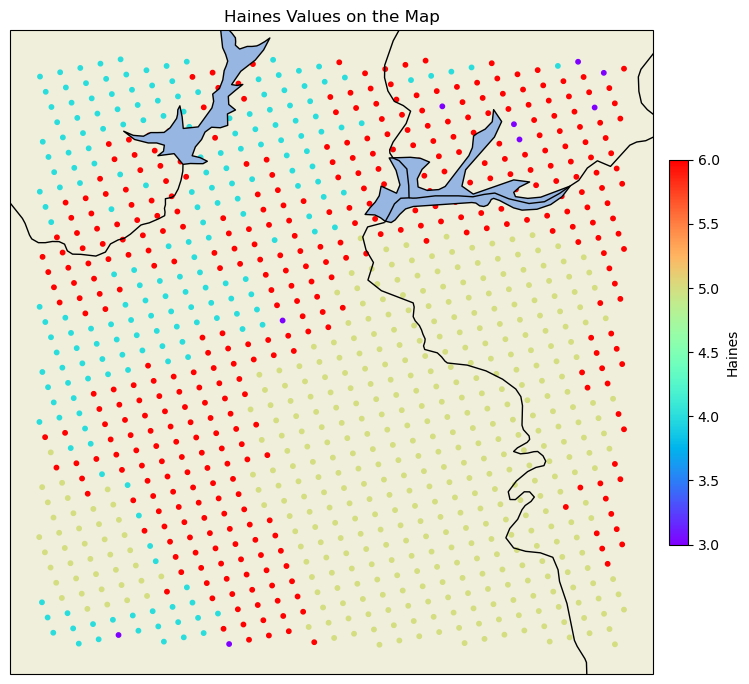

In [123]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize

# Load your data
df = all_data[-1][-1]
df_copy = df.copy()

#df_copy.loc[np.abs(df_copy['SAWTI']) <= 1, 'SAWTI'] = df_copy['SAWTI'] + 1
#df_copy.loc[np.abs(df_copy['SAWTI']) <= 1, 'SAWTI'] = 1

# Create a figure and an axis with a map projection
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': ccrs.PlateCarree()})


# Add features to the map
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, edgecolor='black')
ax.add_feature(cfeature.LAKES, edgecolor='black')
ax.add_feature(cfeature.RIVERS, edgecolor='black')

# Plot the data points
sc = ax.scatter(df['LONG'], df_copy['LAT'], c=df_copy['haines'], cmap='rainbow', s=10, transform=ccrs.PlateCarree())

# Add a color bar
cbar = plt.colorbar(sc, ax=ax, orientation='vertical', shrink=0.5, pad=0.02)
cbar.set_label('Haines')

# Set the title
plt.title('Haines Values on the Map')

# Show the plot
plt.show()
